# Mutual Fund Performance Analytics
This notebook provides deep performance metrics for 40 mutual fund schemes, including risk-adjusted returns, regression analysis against benchmarks, and a composite scorecard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from scipy import stats
from datetime import timedelta

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Define data path relative to project root
BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    PROCESSED_DATA_DIR = BASE_DIR.parent / 'data' / 'processed'
else:
    PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'

def load_data(file_name):
    file_path = PROCESSED_DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find {file_path}. Ensure ETL is run.")
    return pd.read_csv(file_path)

# Load datasets
df_nav = load_data('fact_nav.csv')
df_funds = load_data('dim_fund.csv')
df_benchmarks = load_data('10_benchmark_indices.csv')

# Pre-processing
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_benchmarks['date'] = pd.to_datetime(df_benchmarks['date'])

print("Data loaded successfully.")

Data loaded successfully.


## 1. Compute Daily Returns

In [2]:
# Calculate daily returns for each fund
df_nav = df_nav.sort_values(['amfi_code', 'date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Calculate daily returns for benchmarks
df_bench_pivot = df_benchmarks.pivot(index='date', columns='index_name', values='close_value')
df_bench_returns = df_bench_pivot.pct_change().dropna()

print("Daily returns computed.")

Daily returns computed.


## 2. Risk & Return Metrics (CAGR, Sharpe, Sortino)

In [3]:
rf_annual = 0.065
rf_daily = (1 + rf_annual)**(1/252) - 1

metrics = []

for amfi_code in df_nav['amfi_code'].unique():
    fund_data = df_nav[df_nav['amfi_code'] == amfi_code].set_index('date')
    fund_returns = fund_data['daily_return'].dropna()
    
    if len(fund_returns) < 20: continue
    
    # 1. CAGR Calculation (Assuming daily data covers approximately the periods)
    # Note: For real world, we'd slice exactly 1, 3, 5 years from latest date
    latest_date = fund_data.index.max()
    
    def get_cagr(years):
        start_date = latest_date - timedelta(days=years*365)
        subset = fund_data[fund_data.index >= start_date]
        if len(subset) < 2: return np.nan
        total_return = (subset['nav'].iloc[-1] / subset['nav'].iloc[0]) - 1
        days = (subset.index.max() - subset.index.min()).days
        if days == 0: return np.nan
        return (1 + total_return)**(365/days) - 1

    cagr_1yr = get_cagr(1)
    cagr_3yr = get_cagr(3)
    cagr_5yr = get_cagr(5)
    
    # 2. Sharpe Ratio
    excess_returns = fund_returns - rf_daily
    sharpe = (excess_returns.mean() / fund_returns.std()) * np.sqrt(252)
    
    # 3. Sortino Ratio
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    
    # 4. Max Drawdown
    cum_max = fund_data['nav'].cummax()
    drawdown = (fund_data['nav'] / cum_max) - 1
    max_dd = drawdown.min()
    
    # 5. VaR & CVaR (95%)
    var_95 = np.percentile(fund_returns, 5)
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    
    metrics.append({
        'amfi_code': amfi_code,
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'max_drawdown': max_dd,
        'var_95': var_95,
        'cvar_95': cvar_95
    })

df_metrics = pd.DataFrame(metrics)
print("Risk and Return metrics calculated.")

Risk and Return metrics calculated.


## 3. Alpha & Beta via OLS Regression (against Nifty 50)

In [4]:
regression_results = []
market_returns = df_bench_returns['NIFTY50']

for amfi_code in df_metrics['amfi_code']:
    fund_returns = df_nav[df_nav['amfi_code'] == amfi_code].set_index('date')['daily_return'].dropna()
    
    # Align indices
    aligned_data = pd.concat([fund_returns, market_returns], axis=1).dropna()
    aligned_data.columns = ['fund', 'market']
    
    if len(aligned_data) < 20: continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(aligned_data['market'], aligned_data['fund'])
    
    # Annualized Alpha
    alpha = (intercept * 252)
    beta = slope
    
    regression_results.append({
        'amfi_code': amfi_code,
        'alpha': alpha,
        'beta': beta,
        'r_squared': r_value**2
    })

df_reg = pd.DataFrame(regression_results)
print("Alpha and Beta regression completed.")

Alpha and Beta regression completed.


## 4. Composite Fund Scorecard

In [5]:
# Merge all results with fund master
df_scorecard = df_funds[['amfi_code', 'scheme_name', 'expense_ratio_pct']].merge(df_metrics, on='amfi_code')
df_scorecard = df_scorecard.merge(df_reg, on='amfi_code')

# Normalize function (0 to 100)
def normalize(series, inverse=False):
    if inverse:
        return 100 * (series.max() - series) / (series.max() - series.min())
    return 100 * (series - series.min()) / (series.max() - series.min())

# Scoring logic
df_scorecard['score_3yr_ret'] = normalize(df_scorecard['cagr_3yr'].fillna(df_scorecard['cagr_1yr']))
df_scorecard['score_sharpe'] = normalize(df_scorecard['sharpe_ratio'])
df_scorecard['score_alpha'] = normalize(df_scorecard['alpha'])
df_scorecard['score_expense'] = normalize(df_scorecard['expense_ratio_pct'], inverse=True)
df_scorecard['score_max_dd'] = normalize(df_scorecard['max_drawdown'].abs(), inverse=True)

df_scorecard['composite_score'] = (
    df_scorecard['score_3yr_ret'] * 0.30 +
    df_scorecard['score_sharpe'] * 0.25 +
    df_scorecard['score_alpha'] * 0.20 +
    df_scorecard['score_expense'] * 0.15 +
    df_scorecard['score_max_dd'] * 0.10
)

df_scorecard = df_scorecard.sort_values('composite_score', ascending=False)
print("Composite Scorecard generated.")

Composite Scorecard generated.


## 5. Benchmark Comparison (Top 5 Funds vs Indices)

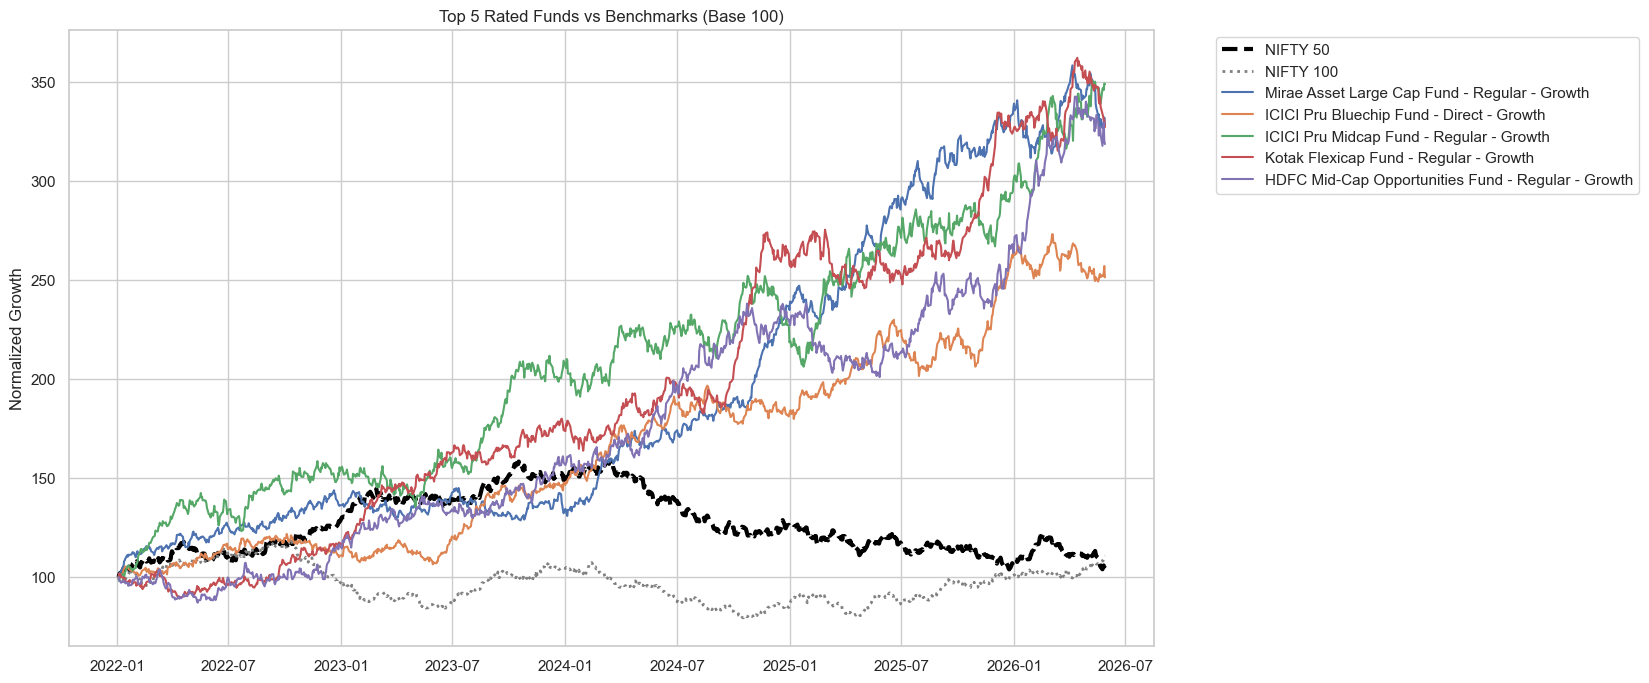

In [6]:
top_5_amfi = df_scorecard.head(5)['amfi_code'].tolist()
top_5_names = df_scorecard.head(5)['scheme_name'].tolist()

plt.figure(figsize=(14, 8))

# Normalize benchmarks for comparison
bench_norm = (df_bench_pivot / df_bench_pivot.iloc[0]) * 100
plt.plot(bench_norm.index, bench_norm['NIFTY50'], label='NIFTY 50', linewidth=3, color='black', linestyle='--')
plt.plot(bench_norm.index, bench_norm['NIFTY100'], label='NIFTY 100', linewidth=2, color='grey', linestyle=':')

for code, name in zip(top_5_amfi, top_5_names):
    fund_nav = df_nav[df_nav['amfi_code'] == code].set_index('date')['nav']
    fund_norm = (fund_nav / fund_nav.iloc[0]) * 100
    plt.plot(fund_norm.index, fund_norm, label=name)

plt.title('Top 5 Rated Funds vs Benchmarks (Base 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Normalized Growth')
plt.show()

## 6. Export Reports

In [7]:
# Export Scorecard
df_scorecard.to_csv(PROCESSED_DATA_DIR / 'fund_scorecard.csv', index=False)

# Export Alpha/Beta
df_reg.to_csv(PROCESSED_DATA_DIR / 'alpha_beta.csv', index=False)

# Export VaR/CVaR
df_var_report = df_metrics[['amfi_code', 'var_95', 'cvar_95']]
df_var_report.to_csv(PROCESSED_DATA_DIR / 'var_cvar_report.csv', index=False)

print(f"Reports exported to {PROCESSED_DATA_DIR}")

Reports exported to c:\Users\gvsp1\OneDrive\Desktop\bluestock_mf_capstone\data\processed


In [ ]:
fund_scorecard = df_scorecard
alpha_beta_df = df_reg
fund_scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
alpha_beta_df.to_csv('../data/processed/alpha_beta.csv', index=False)